In [1]:
#Importing the necessary Libraries for PCA data analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
!pip install kneed
from kneed import KneeLocator

In [2]:
#Loading the data
#File path variables

Local_path = 'C:/Users/beatr/OneDrive/Desktop/WGU/D212/Data/'

InputFilePath = Local_path + 'churn_clean.csv'
OutputfilePath =  Local_path + 'pca_SelectedFeatures_df.csv'
Scaledfilepath = Local_path + 'pca_standardized_df.csv'

Churn_df = pd.read_csv(InputFilePath)

In [3]:
#Initial data exploration (Understanding the data)
pd.set_option('display.max_columns', None)
Churn_df.head()


,CaseOrder,Customer_id,Interaction,UID,City,State,County,Zip,Lat,Lng,Population,Area,TimeZone,Job,Children,Age,Income,Marital,Gender,Churn,Outage_sec_perweek,Email,Contacts,Yearly_equip_failure,Techie,Contract,Port_modem,Tablet,InternetService,Phone,Multiple,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,PaymentMethod,Tenure,MonthlyCharge,Bandwidth_GB_Year,Item1,Item2,Item3,Item4,Item5,Item6,Item7,Item8
0,1,K409198,aa90260b-4141-4a24-8e36-b04ce1f4f77b,e885b299883d4f9fb18e39c75155d990,Point Baker,AK,Prince of Wales-Hyder,99927,56.25100,-133.37571,38,Urban,America/Sitka,Environmental health practitioner,0,68,28561.99,Widowed,Male,No,7.978323,10,0,1,No,One year,Yes,Yes,Fiber Optic,Yes,No,Yes,Yes,No,No,No,Yes,Yes,Credit Card (automatic),6.795513,172.455519,904.536110,5,5,5,3,4,4,3,4
1,2,S120509,fb76459f-c047-4a9d-8af9-e0f7d4ac2524,f2de8bef964785f41a2959829830fb8a,West Branch,MI,Ogemaw,48661,44.32893,-84.24080,10446,Urban,America/Detroit,"Programmer, multimedia",1,27,21704.77,Married,Female,Yes,11.699080,12,0,1,Yes,Month-to-month,No,Yes,Fiber Optic,Yes,Yes,Yes,No,No,No,Yes,Yes,Yes,Bank Transfer(automatic),1.156681,242.632554,800.982766,3,4,3,3,4,3,4,4
2,3,K191035,344d114c-3736-4be5-98f7-c72c281e2d35,f1784cfa9f6d92ae816197eb175d3c71,Yamhill,OR,Yamhill,97148,45.35589,-123.24657,3735,Urban,America/Los_Angeles,Chief Financial Officer,4,50,9609.57,Widowed,Female,No,10.752800,9,0,1,Yes,Two Year,Yes,No,DSL,Yes,Yes,No,No,No,No,No,Yes,Yes,Credit Card (automatic),15.754144,159.947583,2054.706961,4,4,2,4,4,3,3,3
3,4,D90850,abfa2b40-2d43-4994-b15a-989b8c79e311,dc8a365077241bb5cd5ccd305136b05e,Del Mar,CA,San Diego,92014,32.96687,-117.24798,13863,Suburban,America/Los_Angeles,Solicitor,1,48,18925.23,Married,Male,No,14.913540,15,2,0,Yes,Two Year,No,No,DSL,Yes,No,Yes,No,No,No,Yes,No,Yes,Mailed Check,17.087227,119.956840,2164.579412,4,4,4,2,5,4,3,3
4,5,K662701,68a861fd-0d20-4e51-a587-8a90407ee574,aabb64a116e83fdc4befc1fbab1663f9,Needville,TX,Fort Bend,77461,29.38012,-95.80673,11352,Suburban,America/Chicago,Medical illustrator,0,83,40074.19,Separated,Male,Yes,8.147417,16,2,1,No,Month-to-month,Yes,No,Fiber Optic,No,No,No,No,No,Yes,Yes,No,No,Mailed Check,1.670972,149.948316,271.493436,4,4,4,3,4,4,4,5


In [4]:
Churn_df.shape

(10000, 50)

In [5]:
Churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 50 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CaseOrder             10000 non-null  int64  
 1   Customer_id           10000 non-null  object 
 2   Interaction           10000 non-null  object 
 3   UID                   10000 non-null  object 
 4   City                  10000 non-null  object 
 5   State                 10000 non-null  object 
 6   County                10000 non-null  object 
 7   Zip                   10000 non-null  int64  
 8   Lat                   10000 non-null  float64
 9   Lng                   10000 non-null  float64
 10  Population            10000 non-null  int64  
 11  Area                  10000 non-null  object 
 12  TimeZone              10000 non-null  object 
 13  Job                   10000 non-null  object 
 14  Children              10000 non-null  int64  
 15  Age                 

In [6]:
#Data Preprocessing (Cleaning) - includes removing outliers, white spaces, NULL/ NAN 
#values, imputing missing data, binding, one-hot encoding, etc.  

In [7]:
# Select the features that have continous data  for PCA
features_df = Churn_df[['Tenure', 'MonthlyCharge', 'Bandwidth_GB_Year','Outage_sec_perweek']]
features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Tenure              10000 non-null  float64
 1   MonthlyCharge       10000 non-null  float64
 2   Bandwidth_GB_Year   10000 non-null  float64
 3   Outage_sec_perweek  10000 non-null  float64
dtypes: float64(4)
memory usage: 312.6 KB


In [8]:
#Checking for Nulls and missing data
#print(Churn_df.isna().sum().sort_values())
print(features_df[features_df[features_df.columns[features_df .isna().any()]].columns].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Empty DataFrame
None


In [9]:
#Checking for duplicated data 

print("Duplicated rows")
print(features_df.duplicated().any())
print(" ")
print("Duplicated columns")
print(features_df.columns.duplicated().any())


Duplicated rows
False
 
Duplicated columns
False


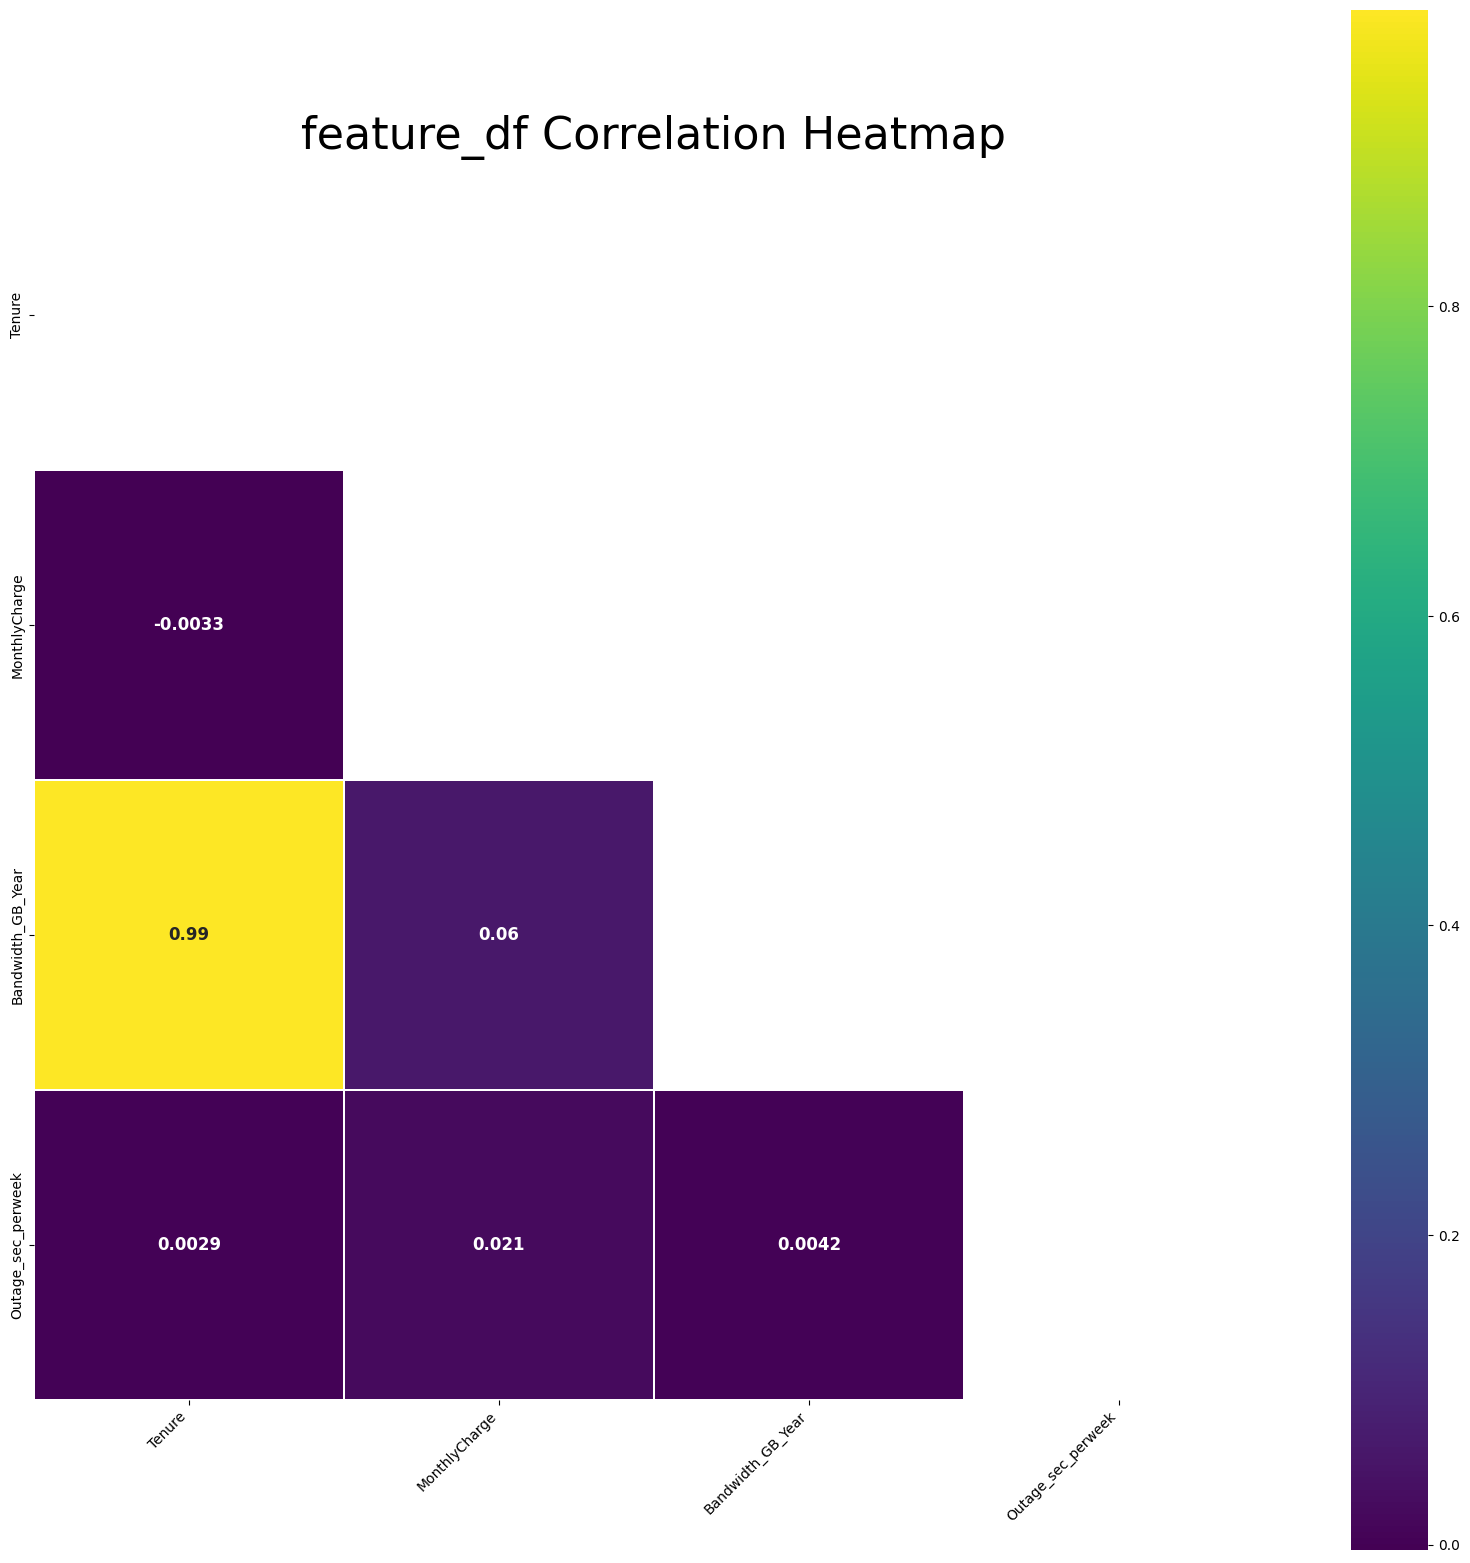

In [10]:
#Analysing the Correlation  /Relationship analysis
Continous_columns = features_df .select_dtypes(include=['float64']).columns.tolist()
Cor_data = features_df [Continous_columns]

def Generate_heatmap_graph(corr, chart_title, mask_uppertri=False):
    """ Based on features, generate a correlation matrix """
    mask = np.zeros_like(corr, dtype=bool)
    mask[np.triu_indices_from(mask)] = mask_uppertri
    fig, ax = plt.subplots(figsize=(20, 20))
    sns.heatmap(corr,
                mask=mask,
                square=True,
                annot=True,
                annot_kws={'size': 12, 'rotation': 0, 'weight': 'bold'},
                cmap=plt.get_cmap('viridis'),
                linewidths=.1,
                ax=ax)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate x-axis labels
    plt.title(chart_title, fontsize=32)
    plt.show()
var_corr = round(Cor_data.corr(), 5)
Generate_heatmap_graph(var_corr, chart_title='feature_df Correlation Heatmap', mask_uppertri=True)

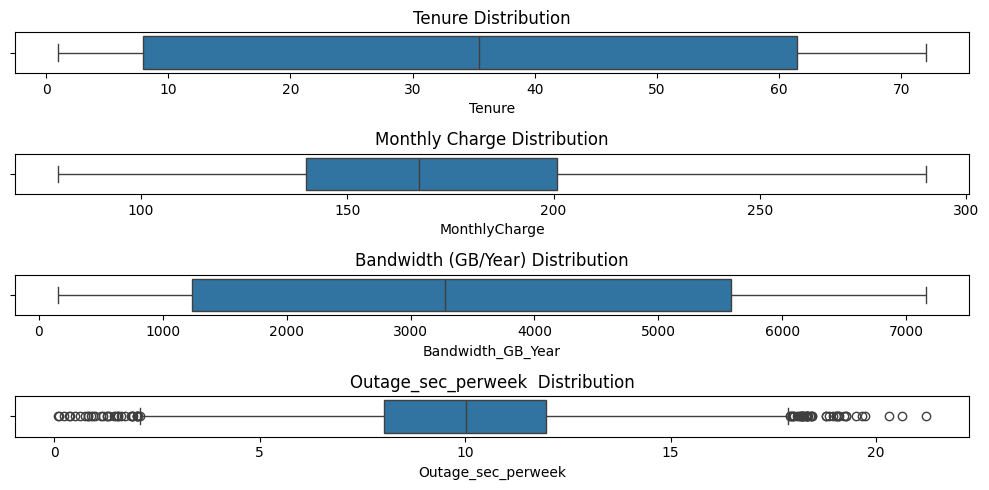

In [11]:
#Checking for outliers 
#Checking for Outliers in the dataset
# Set up the figure and axes
fig, axes = plt.subplots(4, 1, figsize=(10, 5))  

# Flatten axes array for easy indexing
axes = axes.flatten()

# List of column names and titles
cols = ['Tenure', 'MonthlyCharge', 'Bandwidth_GB_Year','Outage_sec_perweek']
titles = ['Tenure Distribution', 
          'Monthly Charge Distribution', 'Bandwidth (GB/Year) Distribution','Outage_sec_perweek  Distribution']

# Create boxplots
for i, col in enumerate(cols):
    sns.boxplot(data=features_df, x=col, ax=axes[i])
    axes[i].set_title(titles[i])
'Tenure Distribution'
# Adjust layout
plt.tight_layout()
plt.show()

In [12]:
#Extracting a copy of the selected features dataset
print(features_df.head().to_string())
features_df.to_csv(OutputfilePath, index=False)


      Tenure  MonthlyCharge  Bandwidth_GB_Year  Outage_sec_perweek
0   6.795513     172.455519         904.536110            7.978323
1   1.156681     242.632554         800.982766           11.699080
2  15.754144     159.947583        2054.706961           10.752800
3  17.087227     119.956840        2164.579412           14.913540
4   1.670972     149.948316         271.493436            8.147417


In [13]:
#Standardizing the data to ensure all features contribute equally
scaler = StandardScaler()
pca_scaled_df = scaler.fit_transform(features_df )


In [14]:
# Extracting a copy of the standardized data
scaled_df = pd.DataFrame(pca_scaled_df, columns=features_df.columns)
print(scaled_df.head().to_string())
scaled_df.to_csv(Scaledfilepath, index=False)


     Tenure  MonthlyCharge  Bandwidth_GB_Year  Outage_sec_perweek
0 -1.048746      -0.003943          -1.138487           -0.679978
1 -1.262001       1.630326          -1.185876            0.570331
2 -0.709940      -0.295225          -0.612138            0.252347
3 -0.659524      -1.226521          -0.561857            1.650506
4 -1.242551      -0.528086          -1.428184           -0.623156


In [15]:
#perform PCA on the data to identify the principal components
pca = PCA()
pca_result = pca.fit_transform(pca_scaled_df)

In [16]:
#Determine the matrix of all the principal components

#Contains new reduced-dimension features dataset that can be used for further analysis

pca_df = pd.DataFrame(pca_result, columns=[f'PC{i+1}' for i in range(pca_result.shape[1])])
print(" matrix of all the principal components :\n", pca_df.head())

 matrix of all the principal components :
         PC1       PC2       PC3       PC4
0 -1.549525 -0.431810 -0.516467 -0.064670
1 -1.659573  1.616766 -0.783327 -0.021744
2 -0.944538  0.001214  0.361592  0.081626
3 -0.903109  0.321420  2.011196  0.123903
4 -1.912215 -0.754555 -0.114259 -0.108945


In [17]:
 #Feature contributions to each principal component
# Each value shows how much a feature contributes to a component
# Helps interpret which features influence each principal component
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(features_df .columns))],
    index=features_df .columns)

top_features_pc1 = loadings['PC1'].sort_values(ascending=False).head(15)
df_top_features_pc1 = pd.DataFrame({
    'Feature': top_features_pc1.index,
    'Loading (PC1)': top_features_pc1.values
})

print(df_top_features_pc1.to_string(index=False))

           Feature  Loading (PC1)
 Bandwidth_GB_Year       0.707163
            Tenure       0.705850
     MonthlyCharge       0.040761
Outage_sec_perweek       0.005898


In [18]:
# Showing top contributing features to each principal component
#The Matrix helps to understand what each principal component represent from my original dataset
num_top_features = 4
num_components_to_show = 4
top_features_set = set()

for i in range(num_components_to_show):
    pc = f'PC{i+1}'
    top_features = loadings[pc].abs().sort_values(ascending=False).head(num_top_features).index
    top_features_set.update(top_features)

top_features_list = list(top_features_set)

matrix = loadings.loc[top_features_list, [f'PC{i+1}' for i in range(num_components_to_show)]]

matrix_sorted = matrix.reindex(matrix['PC1'].abs().sort_values(ascending=False).index)

matrix_sorted_rounded = matrix_sorted.round(4)

print(matrix_sorted_rounded)

                       PC1     PC2     PC3     PC4
Bandwidth_GB_Year   0.7072 -0.0006 -0.0053  0.7070
Tenure              0.7059 -0.0462  0.0399 -0.7057
MonthlyCharge       0.0408  0.7094 -0.7021 -0.0454
Outage_sec_perweek  0.0059  0.7033  0.7109  0.0000


In [19]:
#Identify the total number of principal components- Kaiser criterion
eigenvalues = pca.explained_variance_
kaiser_components = sum(eigenvalues > 1)
print(f"Number of components (Kaiser criterion): {kaiser_components}")

#only the first 2 principal components had eigenvalues greater than 1, 
#hence only those 2 are considered meaningful under the Kaiser criterion.
print (' ')
eigenvalues = pca.explained_variance_
print(f"{'Principal Component':<25}{'Eigenvalue':>15}")
print("-" * 40)
for i, val in enumerate(eigenvalues, 1):
    print(f"{'PC'+str(i):<25}{val:>15.4f}")

Number of components (Kaiser criterion): 2
 
Principal Component           Eigenvalue
----------------------------------------
PC1                               1.9934
PC2                               1.0206
PC3                               0.9800
PC4                               0.0065


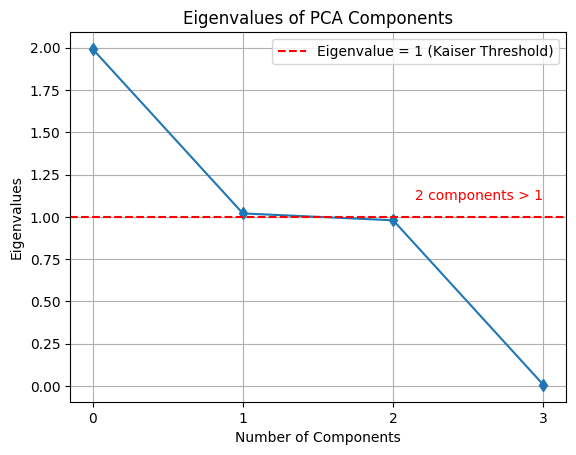

In [20]:
# Extract the eigenvalues or proper values from analysis
#Eigenvalues indicate the magnitude of variance explained by each component
#Visual representation of the Kaiser criterion
cov_matrix = np.dot(pca_scaled_df.T, pca_scaled_df) / pca_scaled_df.shape[0]
Proper_values = [np.dot(eigenvector.T, np.dot(cov_matrix, eigenvector)) for eigenvector in pca.components_]

kaiser_components = sum(np.array(Proper_values) > 1)

plt.plot(range(len(Proper_values)), Proper_values, marker='d', linestyle='-')
plt.axhline(y=1, color='red', linestyle='--', label='Eigenvalue = 1 (Kaiser Threshold)')

# Annotate with the count
plt.text(len(Proper_values)-1, 1.1, f'{kaiser_components} components > 1', color='red', ha='right')

plt.xlabel('Number of Components')
plt.ylabel('Eigenvalues')
plt.title('Eigenvalues of PCA Components')
plt.grid(True)
plt.xticks(np.arange(0, len(Proper_values), 1))
plt.legend()
plt.show()

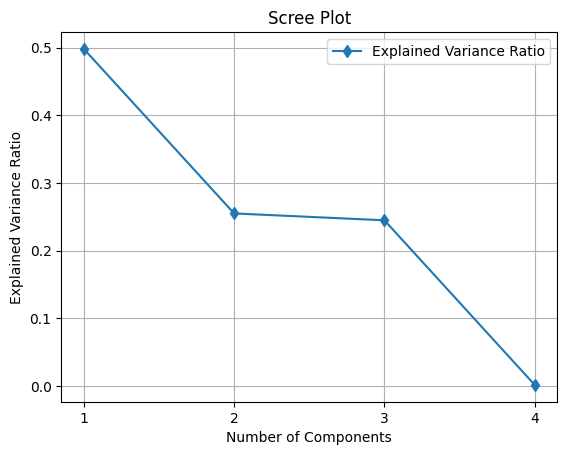

In [21]:
#Identify the total number of principal components- the elbow rule 
# Create the scree plot
#Plot of variance explained by each component
#Helps identify elbow point — where adding more components doesn't add value
# Explained variance ratio from fitted PCA
explained_variance = pca.explained_variance_ratio_
x = np.arange(1, len(explained_variance) + 1)

# Scree plot
plt.plot(x, explained_variance, marker='d', label='Explained Variance Ratio')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.grid(True)
plt.xticks(x)
plt.legend()
plt.show()

In [22]:
# Identify the variance of each component
#amount of variance explained by each individual principal component.
#Calculating principal component explained variance ratio
# Shows how much variance each component explains as a proportion
#Helps decide how many components to keep for maximum information
explained_variance = pca.explained_variance_ratio_
print("Explained Variance:\n",np.round(explained_variance,6).tolist())
print (' ')

print(f"{'Principal Component':<25}{'Explained Variance Ratio':>25}")
print("-" * 55)

for i, val in enumerate(explained_variance, 1):
    print(f"{'PC'+str(i):<25}{val:>25.6f}")


Explained Variance:
 [0.498293, 0.25512, 0.244973, 0.001615]
 
Principal Component       Explained Variance Ratio
-------------------------------------------------------
PC1                                       0.498293
PC2                                       0.255120
PC3                                       0.244973
PC4                                       0.001615


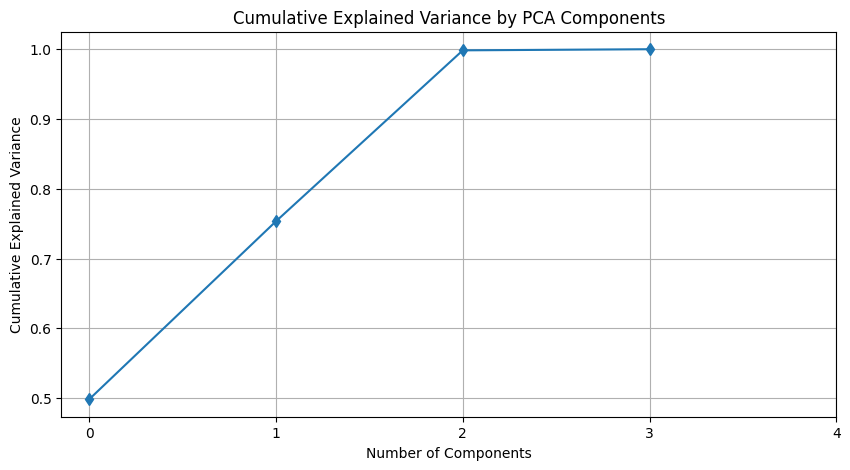

In [23]:
#Cumulative explained variance plot
#Shows how much total variance is captured by top N components
#Helps choose number of components to retain (example to capture 99% variance)

plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(explained_variance), marker='d')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance by PCA Components')
plt.grid(True)
plt.xticks(np.arange(0, len(explained_variance) + 1, 1))
plt.show()


In [24]:
#Identify the total variance captured by the principal components identified in part D2
#cumulative sum of amount of variance explained by each individual principal component.
print("Cumulative Explained Variance:\n", np.round(np.cumsum(explained_variance),6).tolist())
print(' ')
cumulative_variance = np.round(np.cumsum(explained_variance), 6)
df_cumulative = pd.DataFrame({
    "Principal Component": [f"PC{i+1}" for i in range(len(explained_variance))],
    "Cumulative Explained Variance": cumulative_variance
})

print(df_cumulative)
n_components = 2
total_variance = np.sum(explained_variance[:n_components])
print(f"\nTotal variance explained by top {n_components} PCs: {total_variance:.6f}")

Cumulative Explained Variance:
 [0.498293, 0.753413, 0.998385, 1.0]
 
  Principal Component  Cumulative Explained Variance
0                 PC1                       0.498293
1                 PC2                       0.753413
2                 PC3                       0.998385
3                 PC4                       1.000000

Total variance explained by top 2 PCs: 0.753413
